# Detecting an Earth-like planet

This notebook shows how Fig. 17 of the PlatoSim3 paper was created. Note that this notebook both downloads and process the data generated with the `PLATOnium` toolkit. The original simulations were simulated on the super computing facility VSC. Be patient since several of the modules below takes some time to compute (see notes through notebook). 

In [1]:
# Reload code outside noteboo=k
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

In [2]:
import os
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord
from PyAstronomy import pyasl

import scipy.constants as c
from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d
from scipy.stats import binned_statistic

import wotan
import transitleastsquares as tls

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

---
## 1.1 - Fetch simulations
---

In [43]:
# Change the "outputDir" directory below if you want to change the default
odir = os.getcwd()
fdir = 'simulations_PlatoSimPaper2023/hareAndHound'
idir = f'{odir}/{fdir}'

In [4]:
# # Download all files from KUL FTP
# fdir = 'simulations_PlatoSimPaper2023/hareAndHound'
# ut.downloadFromFTP(fdir, odir, server='platodata')

In [5]:
# # Download all files from KUL FTP
# fdir = 'simulations_PlatoSimPaper2023/varsource'
# ut.downloadFromFTP(fdir, odir, server='platodata')

In [47]:
# Load all data into a lightcurve object
lcs = LightCurve(idir, mode="multi")

In [7]:
# Unzip all compressed files
# lcs.unpack()

---
## 1.2 - Input variability model
---

In [8]:
# Fetch the first light curve for this star
lc = LightCurve(lcs.files("ftr")[0])

In [9]:
# Calculate the PLATO passband magnitude of G2V star
ut.passbandConversionV2P(10, 5777, inverse=True)

10.394306041803523

In [10]:
# Get parameter used in input model
varinfo = lc.varsource_info()
P    = varinfo.P_day[0]
t0   = varinfo.t0_day[0]
tdur = wotan.t14(R_s=1, M_s=1, P=P, small_planet=True)
print(f'Orbital period     : {P:.2f} days')
print(f'Time of empherimes : {t0:.2f} days')
print(f'Transit duration   : {tdur*24:.2f} hours')

Orbital period     : 365.25 days
Time of empherimes : 10.00 days
Transit duration   : 12.97 hours


In [11]:
# Show the noise-less light curve used
df_var = lc.varsource()
# Store varibale paraters
time_var = df_var.time / c.day
flux_var = df_var.comb
flux_tra = df_var.tran
# Print components
df_var.head()

,time,gran,puls,tran,occu,beam,elli,comb,spot
0,0.0,-30.227651,3.786619,0.0,0.0,0.000187,-2.756385e-07,-26.441032,0.0
1,25.0,-26.257797,6.413521,0.0,0.0,0.000187,-2.756395e-07,-19.844276,0.0
2,50.0,-11.255772,7.667452,0.0,0.0,0.000187,-2.756405e-07,-3.588321,0.0
3,75.0,-5.799542,7.407067,0.0,0.0,0.000187,-2.756414e-07,1.607525,0.0
4,100.0,-2.566221,5.239296,0.0,0.0,0.000187,-2.756424e-07,2.673075,0.0


<IPython.core.display.Javascript object>


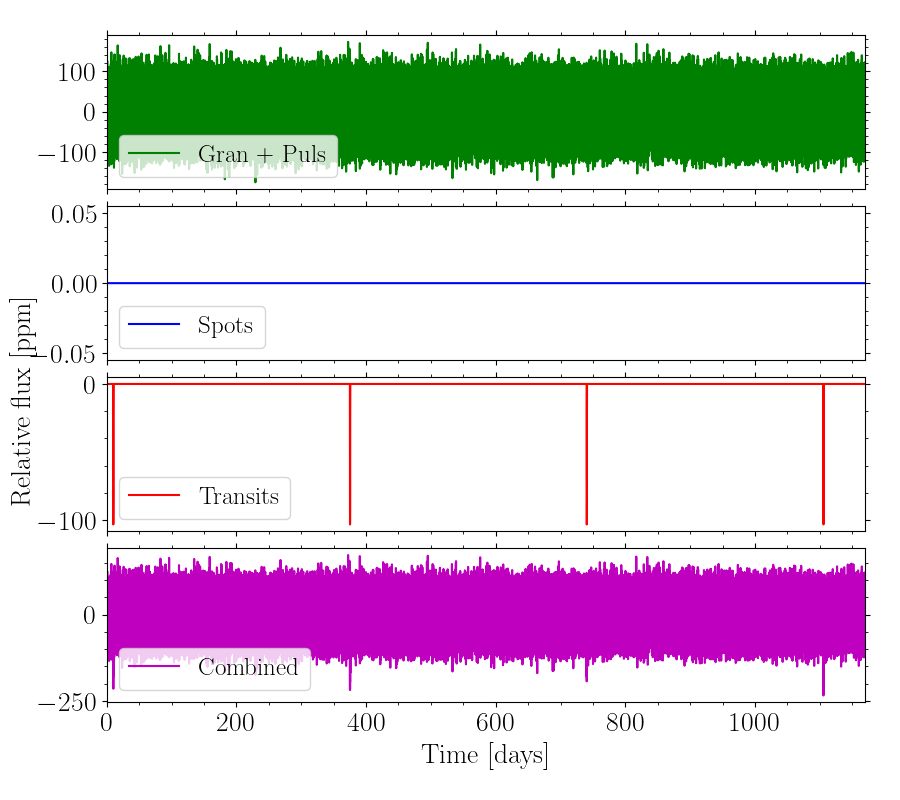

In [12]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

In [13]:
# Compute PSD of granulation and oscillations
freq_gran, psd_gran = periodogram(df_var.gran, 1/25, scaling='density')
freq_puls, psd_puls = periodogram(df_var.puls, 1/25, scaling='density')
freq_gran *= 1e6  # [muHz]
freq_puls *= 1e6  # [muHz]

<IPython.core.display.Javascript object>


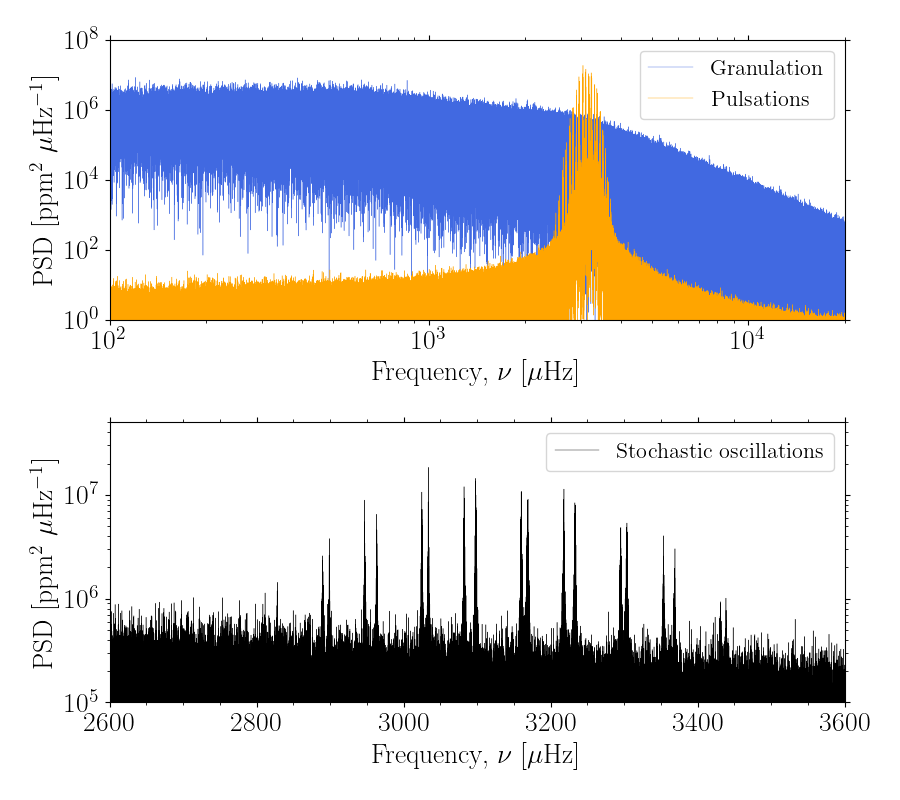

In [14]:
# Creaet plot
fig, ax = plt.subplots(2, 1, figsize=(9,8))
# Plot global model
ax[0].plot(freq_gran, psd_gran, "-", c='royalblue', lw=0.3, label="Granulation")
ax[0].plot(freq_puls, psd_puls, "-", c='orange', lw=0.3, label="Pulsations")
ax[0].set_xlim(1e2, np.max(freq_gran))
ax[0].set_ylim(1e0, 1e8)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[0].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[0].legend(ncol=1, loc='upper right', fontsize=16)
# Plot zoom in on p-modes
ax[1].plot(freq_puls, psd_gran+psd_puls, "-", c='k', lw=0.3, label="Stochastic oscillations")
ax[1].set_xlim(2600, 3600)
ax[1].set_ylim(1e5, 0.5e8)
ax[1].set_yscale('log')
ax[1].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[1].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[1].legend(ncol=1, loc='upper right', fontsize=16)
plt.tight_layout()
# Save figure
fig.savefig('oscillations.png', bbox_inches='tight', dpi=200)

---
## 1.3- Quick-look for a single camera and quarter
---

In [15]:
# Fetch the first light curve for this star
lc = LightCurve(lcs.files("ftr")[0])

In [16]:
# Show the data product
lc.data().head()

,index,time,flux,cx,cy,bg,flux_err,cx_err,cy_err,bg_err
0,0,18.75,405806.493034,2.874434,3.164027,1998.231968,683.866668,0.001015,0.000985,12.647739
1,1,43.75,405385.305088,2.873054,3.164201,2024.426389,683.690000,0.001013,0.000987,12.681930
2,2,68.75,405914.532061,2.877098,3.165001,2023.415495,684.071572,0.001018,0.000986,12.680592
3,3,93.75,407050.367577,2.879893,3.160027,2005.917199,684.861235,0.001020,0.000983,12.659862
4,4,118.75,404604.670541,2.878025,3.161638,2021.047882,683.150624,0.001021,0.000986,12.679649


### Detrending with **Wotan**

The software Wotan is implemented into the detrending module of the `LightCurve` class. We use the robust fitting method cosine description. Note that the detrending works best if you in priori known the full transit time of the planet (i.e. from contact point 1 to 4). We here calculate this period and use is a `window_lenght` detrend criteria:

<IPython.core.display.Javascript object>


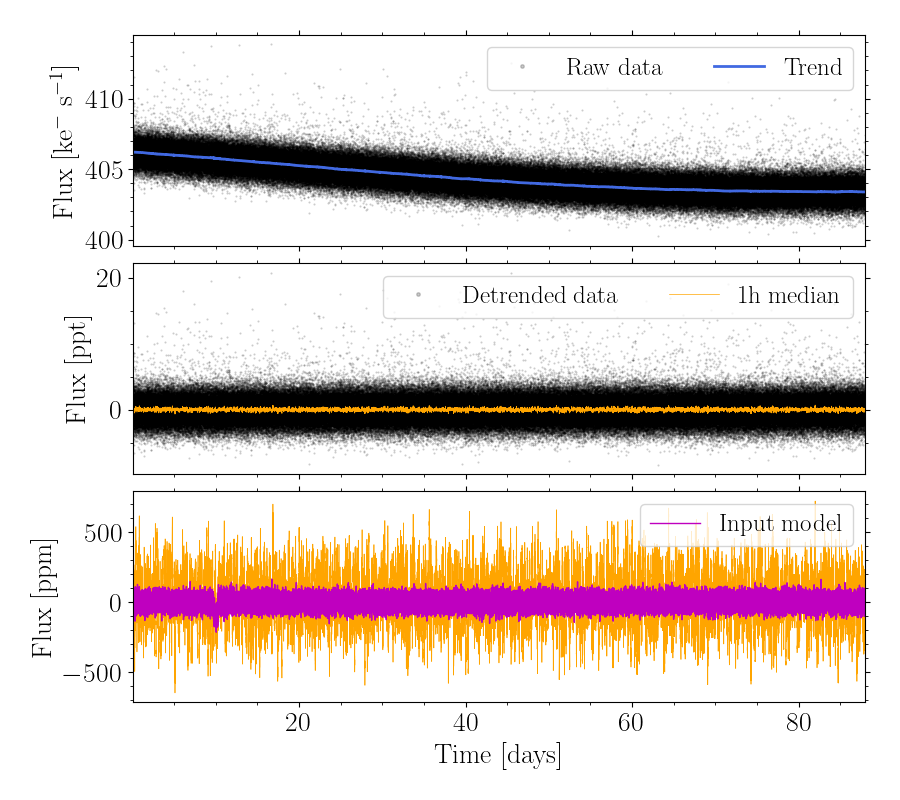

In [17]:
df = lc.detrend(model="wotan", window=3*tdur, mask=[P, tdur, t0], plot=True);

### Outlier rejection with **Scipy**

<IPython.core.display.Javascript object>


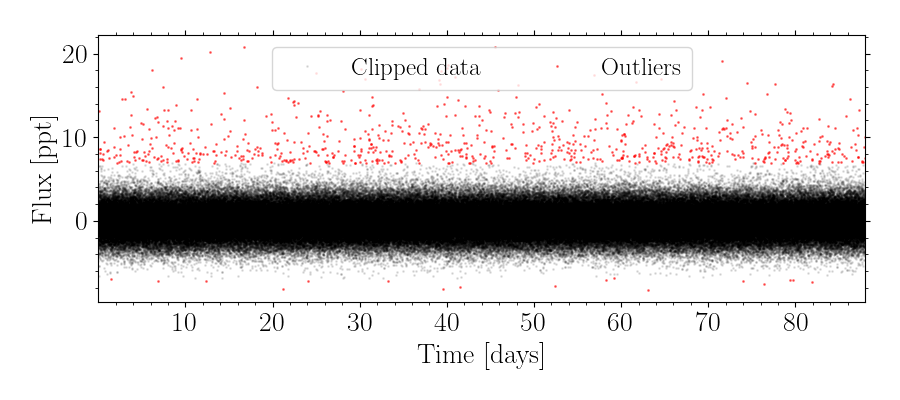

In [18]:
df = lc.clip(model='scipy', low=4, high=4, plot=True);

---
## 1.4 - Vetting for Earth-like transit
---

### Merge into single light curve

Note that commented code-block below shows how to call the function `reduce_star()`, which will first detrend and sigma-clip each mission-quarter light curve individually, and next combine all the light curves into one array and lastly average flux measurements from the same camera group (as they share identical time stamps). The script below takes a few hours to finish (hence why we have commented it out).

In [19]:
# lc = lcs.reduce_star(ofile=f'{idir}/../lc_final_tot.ftr', flux_group_mean=True,
#                     model_detrend='wotan', window=3*tdur, mask=[P, tdur, t0],
#                     model_clip='scipy', low=4, high=4)

Alternatively you can simply download the final light curve prepared for vetting using the above script:

In [20]:
filename = 'simulations_PlatoSimPaper2023/lc_final.ftr'
ut.downloadFromFTP(filename,  os.getcwd(), server='platodata')

In [21]:
# Load the final light curve
lc = LightCurve(f'{idir}/../lc_final.ftr')
df = lc.data()

In [22]:
# Remove small section where the detrending did a bad job
df = df.drop(df[(df.time > 338*c.day) & (df.time < 340*c.day)].index)
time = df.time / c.day
flux = df.flux * 1e6

In [23]:
# Mask transits using Wotan
mask = wotan.transit_mask(time=time, period=P, duration=tdur, T0=t0)
time_mask = time[mask]
flux_mask = flux[mask]

<IPython.core.display.Javascript object>


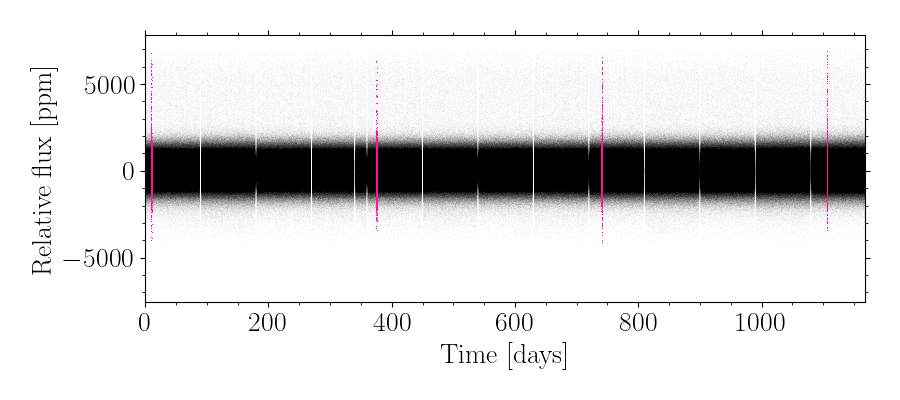

In [24]:
# Plot the corrected timeseries
fig, ax = plt.subplots(1, 1, figsize=(9,4))
ax.plot(time,      flux,      ',', c='k', ms=1.0, alpha=0.01)
ax.plot(time_mask, flux_mask, ',', c='deeppink', ms=1.0, alpha=1)
# Labels
ax.set_xlabel(r"Time [days]")
ax.set_ylabel(r"Relative flux [ppm]")
# Settings
ax.set_xlim(np.min(time), np.max(time))
plt.tight_layout();

### Bin data per 1h

In [25]:
# Resample (bin) data using scipy
bins = int((time.iloc[-1]-time.iloc[0])*24)
flux_bin, time_bin, nbin = binned_statistic(time, flux, statistic='median', bins=bins)
time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.

In [26]:
# Remove extreme outliers
time_bin = time_bin[(flux_bin > -250) & (flux_bin < 250)]
flux_bin = flux_bin[(flux_bin > -250) & (flux_bin < 250)]

<IPython.core.display.Javascript object>


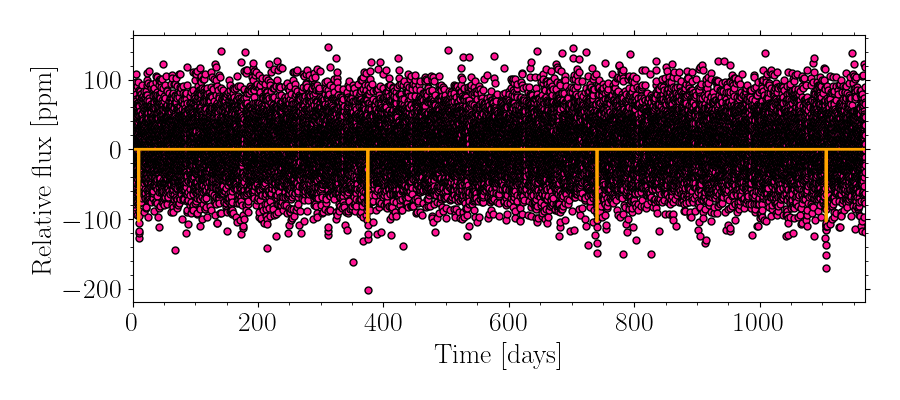

In [27]:
# Plot the corrected timeseries
fig, ax = plt.subplots(1,1,figsize=(9,4))
ax.plot(time_bin, flux_bin, '.', c='deeppink', ms=10,  alpha=1.0, mec='k', label='1h bins');
ax.plot(time_var, flux_tra, '-', c='orange',   lw=2,   alpha=1.0, label='TLS fit')
# Labels
ax.set_xlabel(r"Time [days]")
ax.set_ylabel(r"Relative flux [ppm]")
# Settings
ax.set_xlim(np.min(time), np.max(time))
plt.tight_layout()

### Transit vetting with TLS

In [28]:
# 2 transits
dex2 = np.where((time_bin > 100) & (time_bin < 1000))[0]
time_bin2 = time_bin[dex2]
flux_bin2 = flux_bin[dex2]
flux_bin2 = (flux_bin2 - np.mean(flux_bin2)) / 1e6 + 1

# 3 transits
dex3 = np.where((time_bin > 100) & (time_bin < 1300))[0]
time_bin3 = time_bin[dex3]
flux_bin3 = flux_bin[dex3]
flux_bin3 = (flux_bin3 - np.mean(flux_bin3)) / 1e6 + 1

# 4 transits (entire dataset)
time_bin4 = time_bin
flux_bin4 = flux_bin
flux_bin4 = (flux_bin4 - np.mean(flux_bin4)) / 1e6 + 1

In [29]:
# Function to launch TLS computation 
def run_tls(time, flux): 
    model   = tls.transitleastsquares(time, flux)
    results = model.power(R_star=1.,
                      R_star_min=0.13,
                      R_star_max=3.5,
                      M_star=1.,
                      M_star_min=0.1,
                      M_star_max=1.5,
                      period_min=10., 
                      period_max=400.,
                      n_transits_min=2,
                      use_threads=10)
    return results

In [30]:
# Perform TLS vetting
results4 = run_tls(time_bin4, flux_bin4)
results3 = run_tls(time_bin3, flux_bin3)
results2 = run_tls(time_bin2, flux_bin2)

Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 54 durations
Searching 27419 data points, 45658 periods from 10.0 to 399.988 days
Using 10 of 12 CPU threads


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45658/45658 periods | 03:10<00:00


Searching for best T0 for period 365.25658 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27419/27419 [00:09<00:00, 2859.80it/s]


Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 54 durations
Searching 25067 data points, 41748 periods from 10.001 to 399.985 days
Using 10 of 12 CPU threads


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25067/25067 [00:07<00:00, 3298.54it/s]


Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 54 durations
Searching 21082 data points, 35180 periods from 10.001 to 399.954 days
Using 10 of 12 CPU threads


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35180/35180 periods | 02:03<00:00


Searching for best T0 for period 365.29291 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21082/21082 [00:05<00:00, 3883.24it/s]


In [31]:
print(f'Best period  : [{results2.period:.3f}, {results3.period:.3f}, {results4.period:.3f}] days')
print(f'Best duration: [{results2.duration:.5f}, {results3.duration:.5f}, {results4.duration:.5f}] days')
print(f'Transit depth: [{results2.depth:.5f}, {results3.depth:.5f}, {results4.depth:.5f}]')
print(f'Signal detection efficiency (SDE): [{results2.SDE:.2f}, {results3.SDE:.2f}, {results4.SDE:.2f}]')
print(f'Signal to noise ratio       (SNR): [{results2.snr:.2f}, {results3.snr:.2f}, {results4.snr:.2f}]')

Best period  : [365.293, 365.275, 365.257] days
Best duration: [0.59154, 0.56735, 0.56318] days
Transit depth: [0.99990, 0.99989, 0.99990]
Signal detection efficiency (SDE): [23.58, 39.85, 47.28]
Signal to noise ratio       (SNR): [11.29, 14.78, 16.09]


<IPython.core.display.Javascript object>


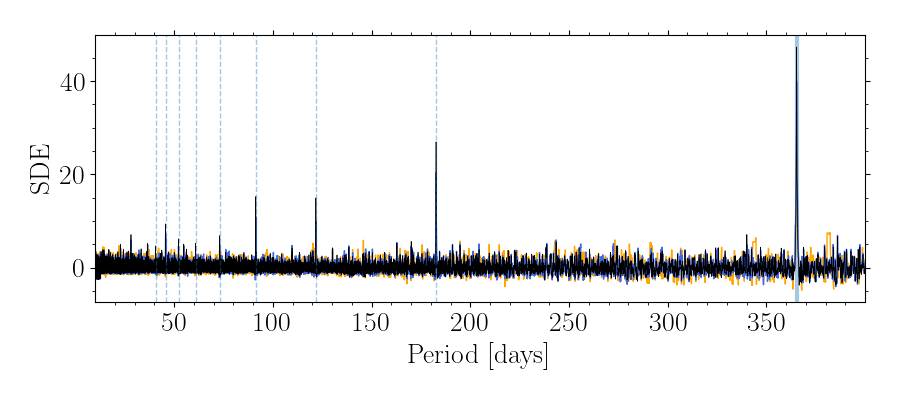

In [32]:
# Plot SDE
plt.figure(figsize=(9,4))
ax = plt.gca()
ax.axvline(results4.period, alpha=0.4, lw=3)
plt.plot(results2.periods, results2.power, c='orange',    lw=1.0)
plt.plot(results3.periods, results3.power, c='royalblue', lw=1.0)
plt.plot(results4.periods, results4.power, c='k',         lw=0.5)
# Plot harmonics from transits
for n in range(2, 10):
    ax.axvline(results4.period / n, alpha=0.4, lw=1, linestyle="dashed")
# Settings
plt.ylabel(r'SDE')
plt.xlabel('Period [days]')
plt.xlim(np.min(results4.periods), np.max(results4.periods))
plt.tight_layout();

### Final plot for paper

In [33]:
# Prepare for phase plot
phase = pyasl.foldAt(time, P, T0=t0+P/2)
sort  = np.argsort(phase)
# For variable
phase_var = pyasl.foldAt(time_var, P, T0=t0+P/2)
sort_var  = np.argsort(phase_var)
# Binned data
phase_bin = pyasl.foldAt(time_bin, P, T0=t0+P/2)
sort_bin  = np.argsort(phase_bin)
# TLS fit for 4 transits
phase_res = results4.model_folded_phase
flux_res  = (results4.model_folded_model-1)*1e6

In [42]:
f = lcs.files(suffix='ftr', group=1, camera=1)
lc = LightCurve(f[0])
lc.data()

,index,time,flux,cx,cy,bg,flux_err,cx_err,cy_err,bg_err
0,0,18.75,405806.493034,2.874434,3.164027,1998.231968,683.866668,0.001015,0.000985,12.647739
1,1,43.75,405385.305088,2.873054,3.164201,2024.426389,683.690000,0.001013,0.000987,12.681930
2,2,68.75,405914.532061,2.877098,3.165001,2023.415495,684.071572,0.001018,0.000986,12.680592
3,3,93.75,407050.367577,2.879893,3.160027,2005.917199,684.861235,0.001020,0.000983,12.659862
4,4,118.75,404604.670541,2.878025,3.161638,2021.047882,683.150624,0.001021,0.000986,12.679649
...,...,...,...,...,...,...,...,...,...,...
304123,304123,7603093.75,402357.447440,2.687315,3.457934,2037.283491,681.806653,0.000823,0.001130,12.703756
304124,304124,7603118.75,402702.403463,2.685820,3.456921,2022.347888,682.085106,0.000822,0.001127,12.688481
304125,304125,7603143.75,404633.423900,2.685179,3.459570,2015.058820,683.433025,0.000818,0.001125,12.677667
304126,304126,7603168.75,403425.248616,2.683493,3.456766,2028.340429,682.714173,0.000820,0.001124,12.699128


In [34]:
# Fetch filenames for N-CAM 1.1 of all quarters
filenames = lcs.files(suffix='ftr', group=1, camera=1)
df0 = pd.DataFrame()
N = len(filenames)
for i,f in zip(range(1,N+1), filenames):
    print(f'Detreding light curve nr {i} out of {N}', end='\r')
    lc = LightCurve(f)
    df = lc.detrend(model="wotan", window=3*tdur, mask=[P, tdur, t0])
    df0[f'time_Q{i}'] = df.time / c.day
    df0[f'flux_Q{i}'] = df.flux_trend / 1e3

<IPython.core.display.Javascript object>


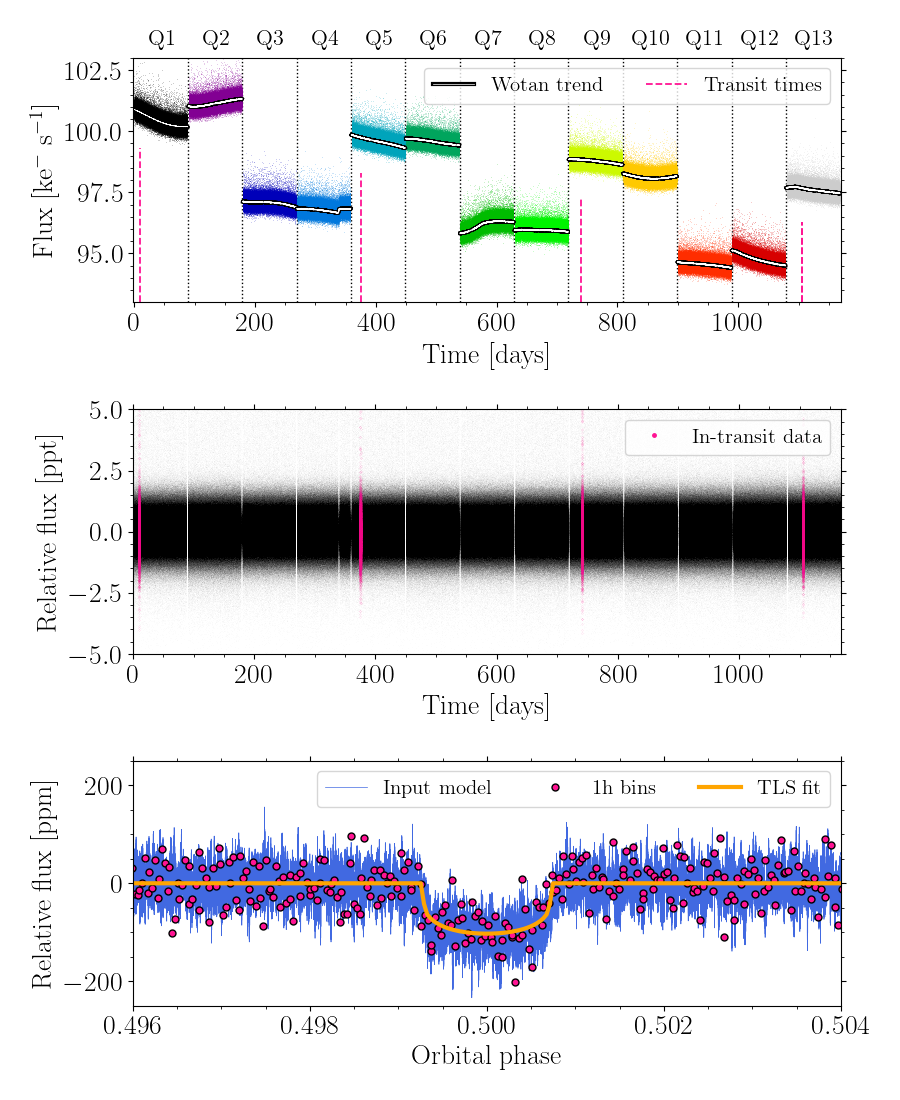

/tmp/ipykernel_141179/1444806228.py:34: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  leg1.legendHandles[0].set_markersize(5)


In [53]:
# Create overview plot of transit vetting
fig, ax0 = lcs.plot_multi(group=1, camera=1, quarter=False, figsize=(9,11))
ax0.set_ylim(93, 103)
# Plot Wotan detrends
import matplotlib.patheffects as mpe                                                                                                                                                          
outline = mpe.withStroke(linewidth=3, foreground='k')
for i in range(1,N+1):
    if i == 1:
        ax0.plot(df0[f'time_Q{i}'], df0[f'flux_Q{i}']/4.026526, '-', c='w', lw=0.5, path_effects=[outline], 
                 label='Wotan trend') 
    else:
        ax0.plot(df0[f'time_Q{i}'], df0[f'flux_Q{i}']/4.026526, '-', c='w', lw=1, path_effects=[outline])                                                                                                                                                                                                                                                                                                  
# Plot transit times for ax 0 and 1
ymax = 0.73
transit_times = np.arange(t0, 4*P, P)
for T in transit_times:
    ymax -= 0.10 
    ax0.axvline(x=T, ymax=ymax, c='deeppink', linestyle='--', lw=1.3)
    if T == transit_times[-1]:
        ax0.axvline(x=T, ymax=ymax, c='deeppink', linestyle='--', lw=1.3, label='Transit times')
#     ax1.axvline(x=T, ymax=0.1,  c='deeppink', linestyle='--', lw=1.3)
ax0.legend(loc='upper right', ncols=2, fontsize=15, frameon=True)
    
# Plot the corrected timeseries
ax1 = fig.add_subplot(312)
ax1.plot(time,       flux/1e3,       ',', c='k', ms=1.0, alpha=0.01)
ax1.plot(time[mask], flux[mask]/1e3, '.', c='deeppink', ms=0.1, alpha=1, label='In-transit data')
# Labels
ax1.set_xlabel(r"Time [days]")
ax1.set_ylabel(r"Relative flux [ppt]")
# Settings
leg1 = ax1.legend(loc='upper right', ncols=1, fontsize=15, frameon=True)
# leg1.legendHandles[0]._legmarker.set_alpha(1)
leg1.legendHandles[0].set_markersize(5)
ax1.set_xlim(np.min(time), np.max(time))
ax1.set_ylim(-5, 5)

# Plot the corrected timeseries
ax2 = fig.add_subplot(313)
ax2.plot(phase_var[sort_var], flux_var[sort_var], '-', c='royalblue', lw=0.5, alpha=1.0, label='Input model')
ax2.plot(phase_bin[sort_bin], flux_bin[sort_bin], '.', c='deeppink',  ms=10,  alpha=1.0, mec='k', label='1h bins')
ax2.plot(phase_res, flux_res, '-', c='orange', lw=3, label='TLS fit')
# Labels
ax2.set_xlabel(r"Orbital phase")
ax2.set_ylabel(r"Relative flux [ppm]")
ax2.legend(loc='upper right', ncols=3, fontsize=15, frameon=True)
# Settings
ax2.set_xlim(0.496, 0.504)
ax2.set_ylim(-250, 250)

# Save the figure
plt.tight_layout(w_pad=0.5)
fig.savefig('transit.png', bbox_inches='tight', dpi=200);    